In [2]:
import os
os.getcwd()

'C:\\Users\\amybr\\OneDrive\\Desktop\\DS\\Final Presentation 690 and Project 691'

In [3]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
connection = psycopg2.connect(
    host="localhost",
    port="5432",
    dbname="final_project",
    user="postgres",
    password="awesomeamy"
)

#load all 8 tables into pandas DataFrames
credit_df = pd.read_sql("SELECT * FROM credit_data", connection)
crypto_df = pd.read_sql("SELECT * FROM cryptocurrency", connection)
econ_df = pd.read_sql("SELECT * FROM economic_indicators", connection)
exchange_df = pd.read_sql("SELECT * FROM exchange_rates", connection)
housing_df = pd.read_sql("SELECT * FROM housing_data", connection)
interest_df = pd.read_sql("SELECT * FROM interest_rates", connection)
market_df = pd.read_sql("SELECT * FROM market_data", connection)
sentiment_df = pd.read_sql("SELECT * FROM sentiment_data", connection)

#close the database connection
connection.close()

#ensure all date cols are in datetime format
for df in [
    credit_df, crypto_df, econ_df, exchange_df, housing_df, interest_df, market_df, sentiment_df
]:
    df['date'] = pd.to_datetime(df['date'])

C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\244502447.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_df = pd.read_sql("SELECT * FROM credit_data", connection)
C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\244502447.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  crypto_df = pd.read_sql("SELECT * FROM cryptocurrency", connection)
C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\244502447.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  econ_df = pd.read_sql("SELECT * FROM economic_indicators"

In [ ]:
#data structures
for name, df in zip([
    'credit', 'crypto', 'economic_indicators', 'exchange_rates', 'housing', 'interest_rates', 'market', 'sentiment'
], [credit_df, crypto_df, econ_df, exchange_df, housing_df, interest_df, market_df, sentiment_df]):
    print(f" --- {name.upper()} ---") #upper case for easier reading
    print(df.info())
    print(df.describe(include='all').transpose()) #to flip rows and cols for easier reading
    print("\n") #adding a line for easier reading

In [6]:
#see all missing values, charge_off and consumer_loans_delinq rate not available until 1985
credit_df.isna().sum()

date                                 0
consumer_credit_outstanding          0
charge_off_rate                    122
consumer_loans_delinquency_rate    122
household_debt_service_ratio        62
total_bank_credit                    0
real_estate_credit_outstanding       0
total_credit_outstanding             0
consumer_credit_exposure_ratio       0
real_estate_exposure_ratio           0
total_credit_exposure_ratio          0
dtype: int64

In [7]:
#see all missing values
crypto_df.isna().sum()

date                       0
btc_price                  0
btc_volume                 0
btc_market_cap             0
eth_price                 61
eth_volume                61
eth_market_cap            61
btc_circulating_supply     0
eth_circulating_supply    61
dtype: int64

In [8]:
#see all missing values, breakeven rate not available until 2003
econ_df.isna().sum()

date                         0
gdp                          2
core_cpi_index               0
cpi_index                    0
breakeven_rate_avg         336
ipi_index                    0
ppi_index                    0
total_employees              0
unemployment_rate            0
crude_oil_price              0
gold_price                   0
silver_price                 0
gdp_real                     2
unemployment_rate_level      0
gdp_real_yoy_change         14
inflation_yoy               12
inflation_mom                1
core_inflation_mom           1
core_inflation_yoy          12
dtype: int64

In [9]:
#see all missing values, usd_fx_index not available until 2006, cny not available until 1981, eur_usd not exist until 1999
exchange_df.isna().sum()

date                         0
usd_fx_index               372
aud_usd                      0
eur_usd                    288
gbp_usd                      0
cad_usd                      0
cny_usd                     72
jpy_usd                      0
chf_usd                      0
usd_fx_index_volatility    373
usd_strength_level           0
usd_average_fx_rate        288
dtype: int64

In [10]:
#see all missing values, homes_sold not available until 2008
housing_df.isna().sum()

date                               0
real_estate_credit                 0
housing_price_index                2
prime_rate                         0
housing_inventory                  0
mortgage_rates_avg                 0
homes_sold                       397
real_estate_credit_mom_change      1
mortgage_rate_level                0
price_to_mortgage_rate_ratio       2
dtype: int64

In [11]:
#see all missing values, sofr not available until 2018, libor ending in 2016
interest_df.isna().sum()

date                    0
tbill_3mo               1
libor                  99
sofr_avg              519
fed_funds_avg           0
tsec_10yr_avg           0
moody_aaa               1
yield_curve_proxy       1
policy_stance_rate      1
policy_stance           1
dtype: int64

In [12]:
#see all missing values, nasdaq not available until 1986
market_df.isna().sum()

date                             0
sp500_index_real                 0
sp500_index_nominal              0
djia_index_real                  0
djia_index_nominal               0
nasdaq100_index_avg            132
market_momentum                  1
market_trend                     0
nasdaq100_index_rolling_avg    132
nasdaq100_index_avg_real       603
dtype: int64

In [13]:
#see all missing values, google not available until 2004
sentiment_df.isna().sum()

date                               0
vix_index_avg                      0
business_sentiment                14
consumer_sentiment                 0
google_inflation_trend           168
google_interest_rate_trend       168
google_mortgage_rate_trend       168
consumer_confidence_index          3
vix_volatility_level               0
consumer_sentiment_mom_change      1
consumer_sentiment_level           0
dtype: int64

C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\3058089574.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  yield_curve_df = pd.read_sql(query, connection)


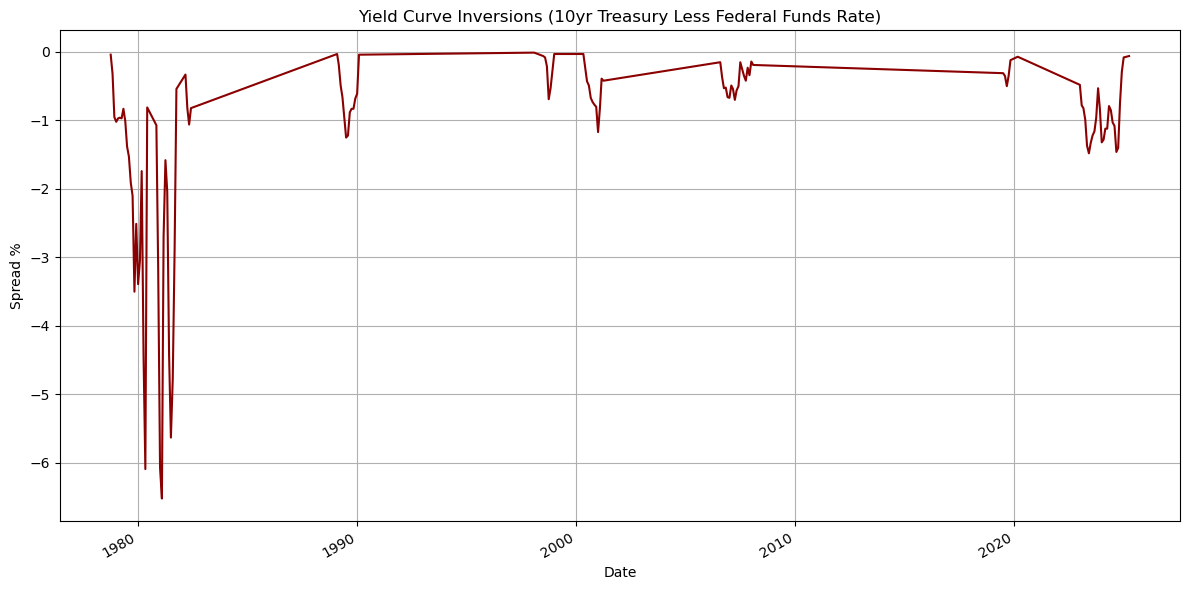

In [121]:
#yield curve to identify recession warning signals, inverted
query = """
SELECT date, tsec_10yr_avg - fed_funds_avg AS curve_spread
FROM interest_rates 
WHERE (tsec_10yr_avg - fed_funds_avg) < 0
ORDER BY date;
"""

connection = psycopg2.connect(
    host="localhost",
    port="5432",
    dbname="final_project",
    user="postgres",
    password="awesomeamy"
)

yield_curve_df = pd.read_sql(query, connection)
connection.close()

#convert date and plot
yield_curve_df['date'] = pd.to_datetime(yield_curve_df['date'])
yield_curve_df.set_index('date', inplace=True)

plt.figure(figsize=(12, 6))
yield_curve_df['curve_spread'].plot(color='darkred')
plt.title("Yield Curve Inversions (10yr Treasury Less Federal Funds Rate)")
plt.ylabel("Spread %")
plt.xlabel("Date")
plt.xticks()
plt.grid(True)
plt.tight_layout()

plt.savefig("1.recession_yield_curve_inversion.png", dpi=300, bbox_inches='tight')

plt.show()


C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\1411969171.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fed_funds_cpi_df = pd.read_sql(query, connection)


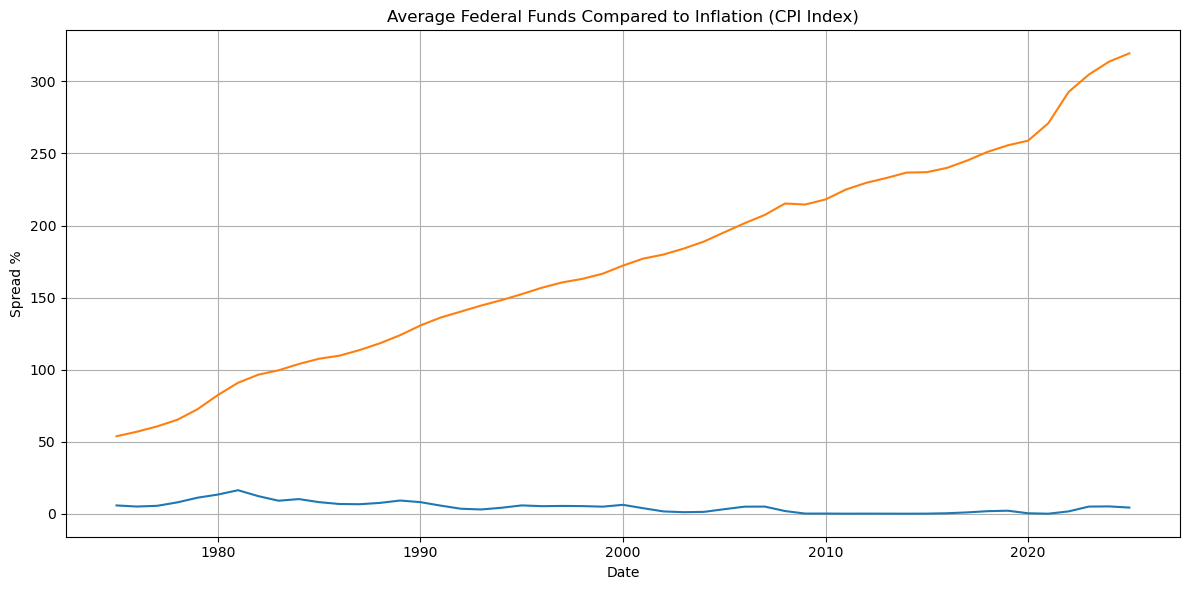

In [14]:
#avg fed funds rate and avg cpi by year to show how monetary policy and inflation move together. yearly avg for fed funds monthly avg
query = """
SELECT
	EXTRACT(YEAR FROM ir.date)::INT AS year,
	ROUND(AVG(ir.fed_funds_avg), 2) AS avg_fed_funds_avg,
	ROUND(AVG(e.cpi_index), 2) AS avg_cpi_index
FROM interest_rates ir
JOIN economic_indicators e
	ON ir.date = e.date
GROUP BY year
ORDER BY year;
"""

connection = psycopg2.connect(
    host="localhost",
    port="5432",
    dbname="final_project",
    user="postgres",
    password="awesomeamy"
)

fed_funds_cpi_df = pd.read_sql(query, connection)
connection.close()

fed_funds_cpi_df['year'] = fed_funds_cpi_df['year'].astype(int)

plt.figure(figsize=(12, 6))
plt.plot(fed_funds_cpi_df['year'], fed_funds_cpi_df['avg_fed_funds_avg'], label="Average Federal Funds Rate")
plt.plot(fed_funds_cpi_df['year'], fed_funds_cpi_df['avg_cpi_index'], label="Average CPI Index")
plt.title("Average Federal Funds Compared to Inflation (CPI Index)")
plt.ylabel("Spread %")
plt.xlabel("Date")
plt.xticks()
plt.grid(True)
plt.tight_layout()
plt.show()

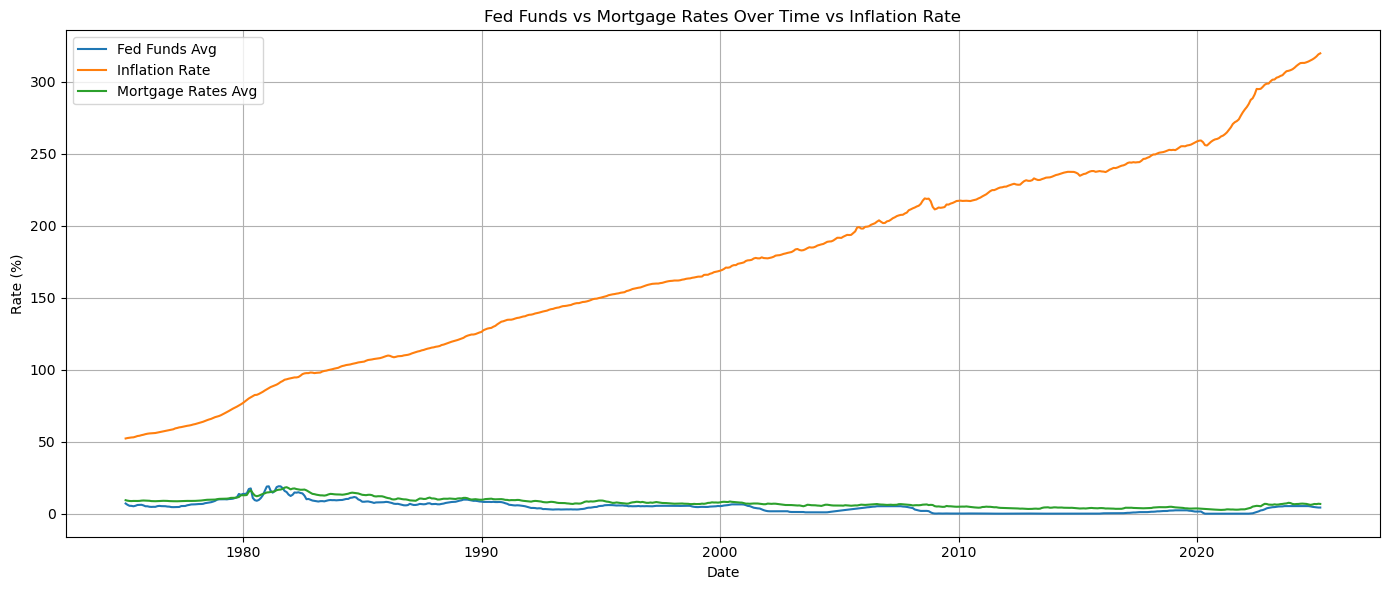

In [15]:
#fed funds vs. mortgage rate vs. inflation

#sort by date
interest_df = interest_df.sort_values('date')
econ_df = econ_df.sort_values('date')
housing_df = housing_df.sort_values('date')

#merge data
interest_econ = pd.merge(interest_df, econ_df, on='date', how='inner')
merged = pd.merge(interest_econ, housing_df[['date', 'mortgage_rates_avg']], on='date', how='inner')

#plot
plt.figure(figsize=(14, 6))
plt.plot(merged["date"], merged["fed_funds_avg"], label="Fed Funds Avg")
plt.plot(merged["date"], merged["cpi_index"], label="Inflation Rate")
plt.plot(merged["date"], merged["mortgage_rates_avg"], label="Mortgage Rates Avg")
plt.legend()
plt.title("Fed Funds vs Mortgage Rates Over Time vs Inflation Rate")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


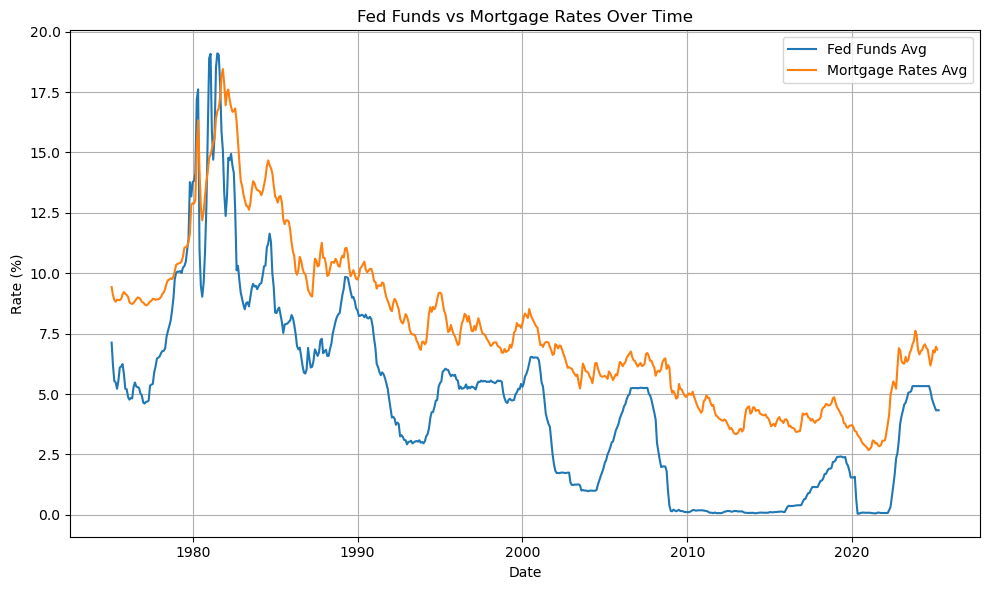

In [117]:
#fed funds to mortgage rates - have to sort by date to ensure accurate time-based visualization
interest_df['date'] = pd.to_datetime(interest_df['date'])
housing_df['date'] = pd.to_datetime(housing_df['date'])

interest_df = interest_df.sort_values('date')
housing_df = housing_df.sort_values('date')

plt.figure(figsize=(10, 6))
plt.plot(interest_df["date"], interest_df["fed_funds_avg"], label="Fed Funds Avg")
plt.plot(housing_df["date"], housing_df["mortgage_rates_avg"], label="Mortgage Rates Avg")
plt.legend()
plt.title("Fed Funds vs Mortgage Rates Over Time")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.tight_layout()

plt.savefig("line_mtg_to_fed_funds.png", dpi=300, bbox_inches='tight')

plt.show()

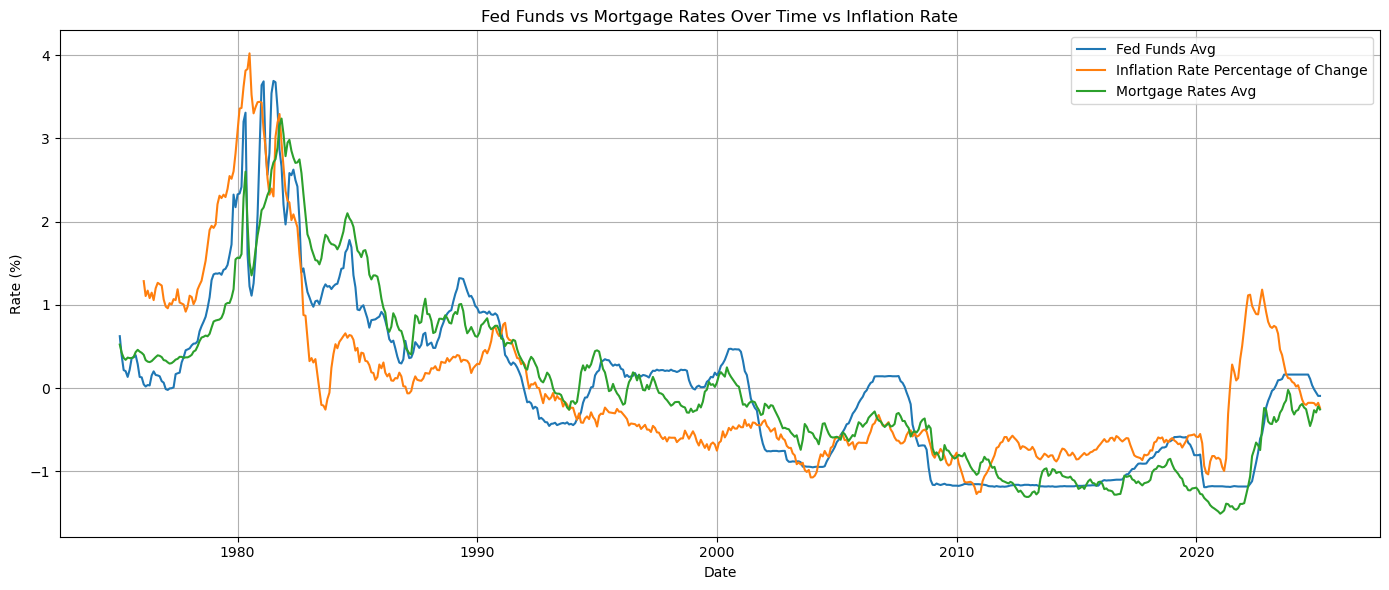

In [119]:
#we need to standardize this
from sklearn.preprocessing import StandardScaler

#sort by date
interest_df = interest_df.sort_values('date')
econ_df = econ_df.sort_values('date')
housing_df = housing_df.sort_values('date')

#merge data
interest_econ = pd.merge(interest_df, econ_df, on='date', how='inner')
merged = pd.merge(interest_econ, housing_df[['date', 'mortgage_rates_avg']], on='date', how='inner')

#standardize
scaler = StandardScaler()
cols_to_scale = ['core_inflation_yoy', 'fed_funds_avg', 'mortgage_rates_avg']

standardized_df = merged.copy()
standardized_df[cols_to_scale] = scaler.fit_transform(standardized_df[cols_to_scale])

#plot
plt.figure(figsize=(14, 6))
plt.plot(standardized_df["date"], standardized_df["fed_funds_avg"], label="Fed Funds Avg")
plt.plot(standardized_df["date"], standardized_df["core_inflation_yoy"], label="Inflation Rate Percentage of Change")
plt.plot(standardized_df["date"], standardized_df["mortgage_rates_avg"], label="Mortgage Rates Avg")
plt.legend()
plt.title("Fed Funds vs Mortgage Rates Over Time vs Inflation Rate")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.tight_layout()

plt.savefig("line_mtg_funds_int.png", dpi=300, bbox_inches='tight')

plt.show()

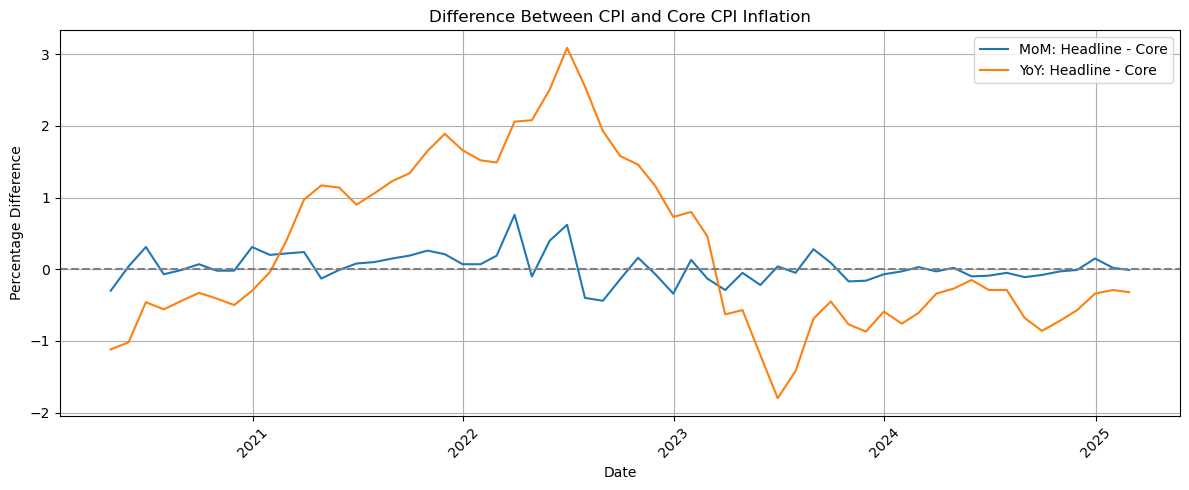

In [19]:
#difference between core_cpi and cpi for the last 5 years
econ_df = econ_df.sort_values('date')

econ_df['date'] = pd.to_datetime(econ_df['date'])
econ_df = econ_df.set_index('date')

econ_df['mom_diff'] = econ_df['inflation_mom'] - econ_df['core_inflation_mom']
econ_df['yoy_diff'] = econ_df['inflation_yoy'] - econ_df['core_inflation_yoy']

five_years = pd.Timestamp.today() - pd.DateOffset(years=5)
recent_df = econ_df[econ_df.index >= five_years]

plt.figure(figsize=(12, 5))
plt.plot(recent_df.index, recent_df['mom_diff'], label='MoM: Headline - Core')
plt.plot(recent_df.index, recent_df['yoy_diff'], label='YoY: Headline - Core')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Difference Between CPI and Core CPI Inflation')
plt.ylabel('Percentage Difference')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#create a combined df for all
combined_df = interest_df.copy()

combined_df = combined_df.merge(econ_df, on='date', how='outer')
combined_df = combined_df.merge(credit_df, on='date', how='outer')
combined_df = combined_df.merge(market_df, on='date', how='outer')
combined_df = combined_df.merge(sentiment_df, on='date', how='outer')
combined_df = combined_df.merge(exchange_df, on='date', how='outer')
combined_df = combined_df.merge(crypto_df, on='date', how='outer')
combined_df = combined_df.merge(housing_df, on='date', how='outer')

combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')
combined_df = combined_df.sort_index()

print(combined_df.head())

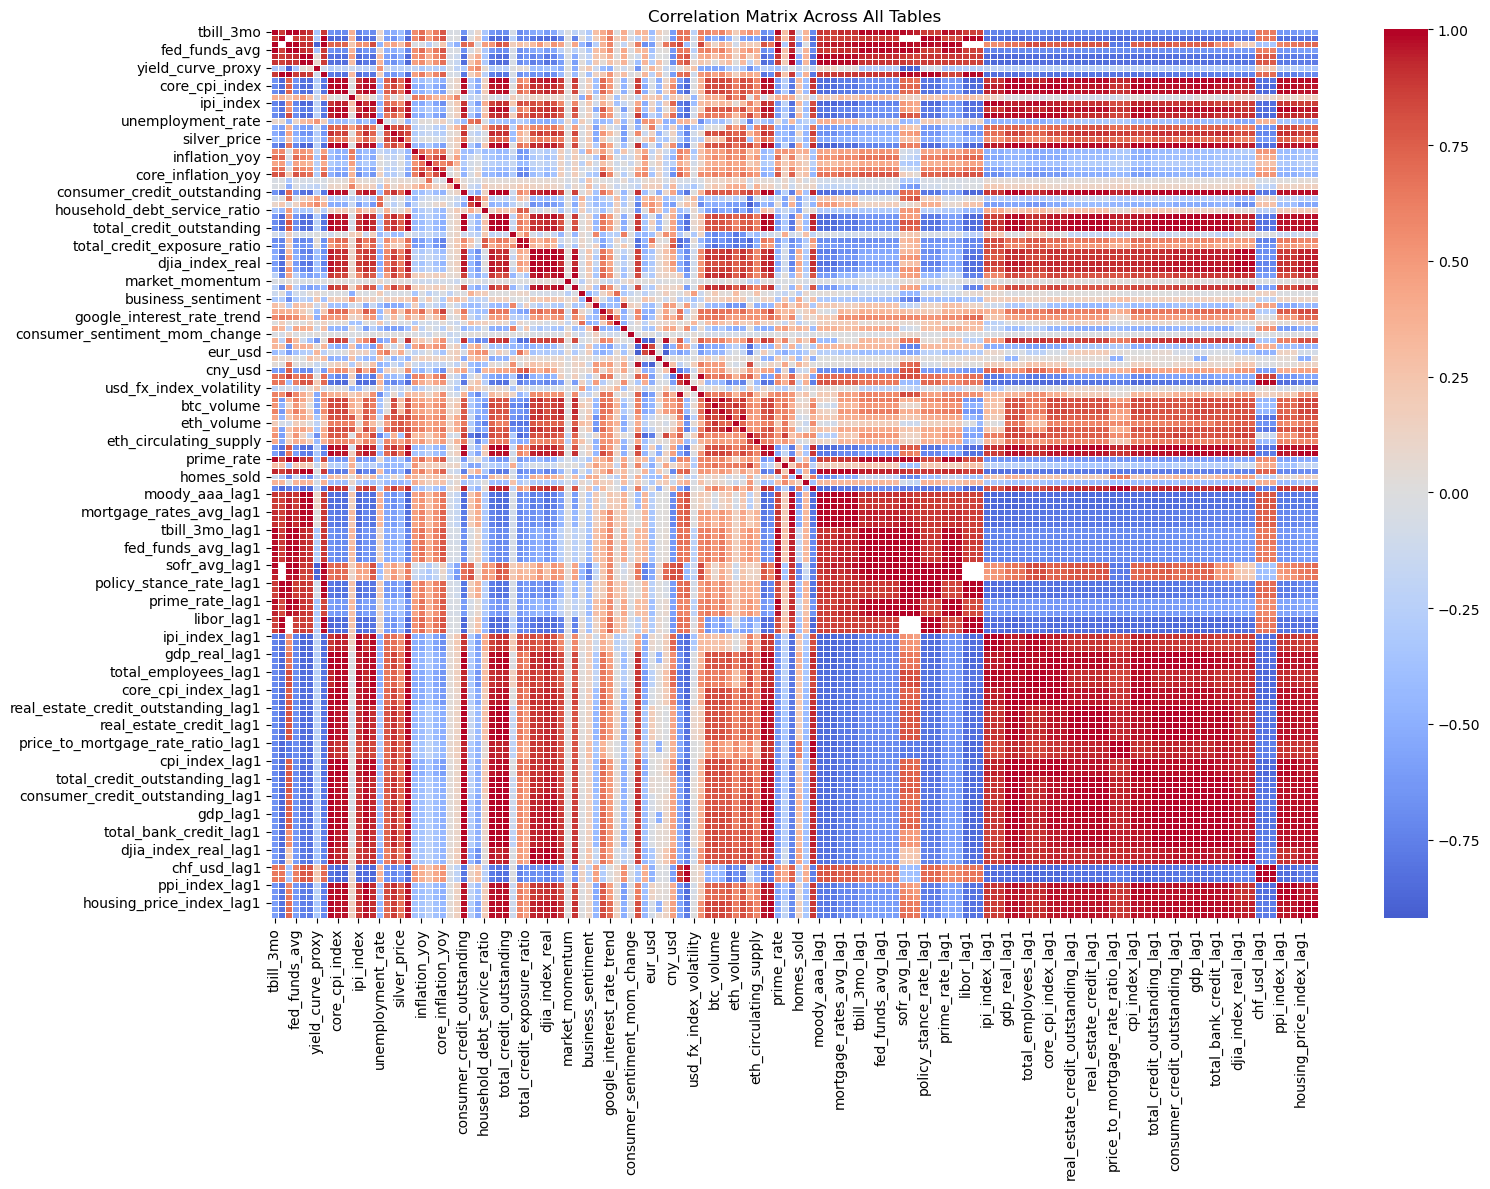

In [123]:
#heatmap of all
numeric_cols = combined_df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidth=0.5)
plt.title('Correlation Matrix Across All Tables')
plt.tight_layout()

plt.savefig("heatmap_all_corr.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#keeping only numeric cols because all text cols were ones I added
numeric_df = combined_df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

#unstack
strong_corrs = corr_matrix.abs().unstack().reset_index()
strong_corrs.columns = ['Variable1', 'Variable2', 'Correlation']

#nice cols and drop dups
strong_corrs = strong_corrs[strong_corrs['Variable1'] < strong_corrs['Variable2']]
strong_corrs = strong_corrs[strong_corrs['Variable1'] != strong_corrs['Variable2']]

#filter
filtered_strong_corrs = strong_corrs[strong_corrs['Correlation'].abs() > .25]

#sort
filtered_strong_corrs = filtered_strong_corrs.sort_values(by='Correlation', ascending=False)

#to string so easy to read full
print(filtered_strong_corrs.to_string(index=False))

In [ ]:
#narrowing down using policy_rate as target
policy_rate_corr = numeric_df.corr()['policy_stance_rate'].drop('policy_stance_rate')
filtered_policy_rate_corr = policy_rate_corr[abs(policy_rate_corr) > .25].sort_values(key=abs, ascending=False)
print(filtered_policy_rate_corr.to_string())

In [ ]:
#narrowing down using tsec_10yr_avg as target
tsec_corr = numeric_df.corr()['tsec_10yr_avg'].drop('tsec_10yr_avg')
filtered_tsec_corr = tsec_corr[abs(tsec_corr) > .25].sort_values(key=abs, ascending=False)
print(filtered_tsec_corr.to_string())

In [ ]:
#need to narrow down more using tsec_10yr_avg
tsec_stronger_corr = numeric_df.corr()['tsec_10yr_avg'].drop('tsec_10yr_avg')
filtered_tsec_stronger_corr = tsec_stronger_corr[abs(tsec_stronger_corr) > .75].sort_values(key=abs, ascending=False)
print(filtered_tsec_stronger_corr.to_string())

In [ ]:
#compare tsec to policy_rate to see side-by-side comparison
policy_corr = numeric_df.corr()['policy_stance_rate'].drop('policy_stance_rate')
tsec_corr = numeric_df.corr()['tsec_10yr_avg'].drop('tsec_10yr_avg')

filtered_policy = policy_corr[policy_corr.abs() > 0.75].sort_values(key=abs, ascending=False)
filtered_tsec = tsec_corr[tsec_corr.abs() > 0.75].sort_values(key=abs, ascending=False)

comparison_df = pd.DataFrame({
    'Policy_Correlation': filtered_policy,
    'TSEC_Correlation': filtered_tsec
})

comparison_df = comparison_df.dropna(how='all')

sorted_by_policy = comparison_df.sort_values(by='Policy_Correlation', ascending=False)

print(sorted_by_policy)                                           

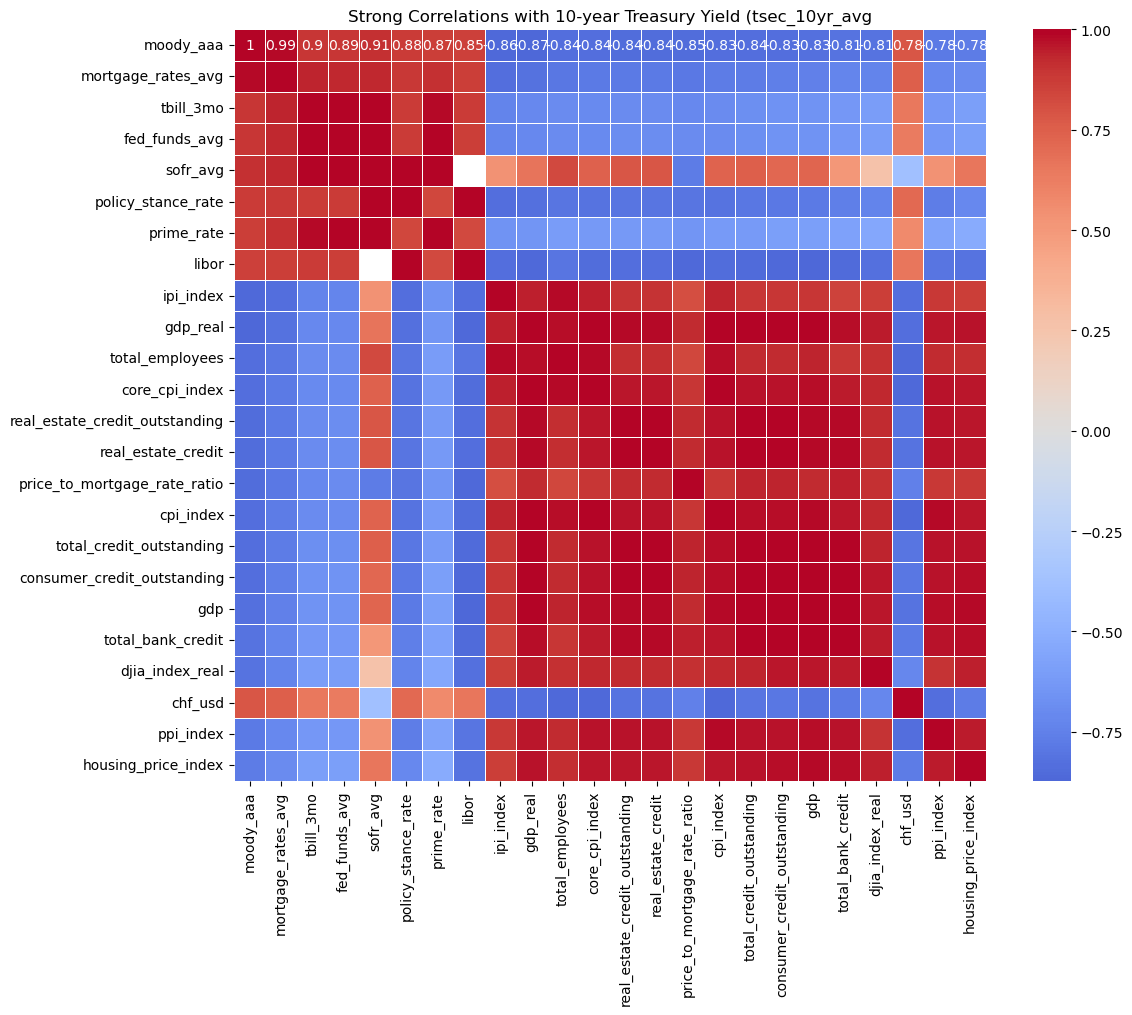

In [125]:
#heatmap of corrs > .75 with tsec as target
tsec_stronger_corr_vars = filtered_tsec_stronger_corr.index

filtered_tsec_stronger_corr_matrix = numeric_df.corr().loc[tsec_stronger_corr_vars, tsec_stronger_corr_vars]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_tsec_stronger_corr_matrix, cmap='coolwarm', center=0, annot=True, linewidth=0.5, square=True)
plt.title('Strong Correlations with 10-year Treasury Yield (tsec_10yr_avg')
plt.tight_layout()

plt.savefig("heatmap_corrs_75.png", dpi=300, bbox_inches='tight')

plt.show()

C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\1725044253.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tsec_predictors_df = pd.read_sql(query, connection)


<Axes: title={'center': 'TSEC and Top Predictors (2020–2025)'}, xlabel='date'>

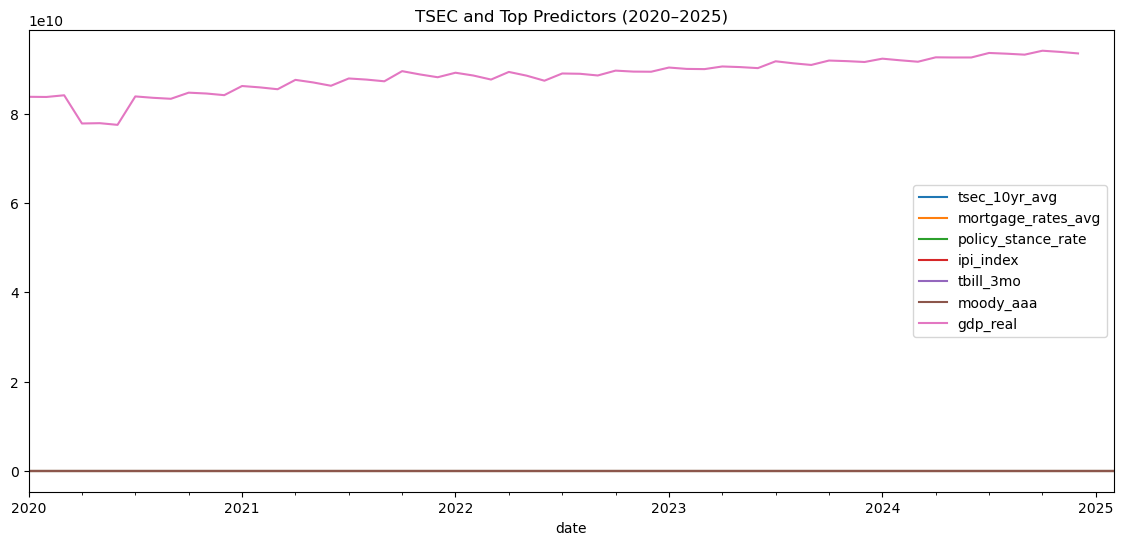

In [29]:
#sql query for 5 top predictors from 2020 thru current
query = """
SELECT i.date,
		i.tsec_10yr_avg,
		h.mortgage_rates_avg,
		i.policy_stance_rate,
		e.ipi_index,
        i.tbill_3mo,
		i.moody_aaa,
        e.gdp_real
FROM interest_rates i
JOIN housing_data h ON i.date = h.date
JOIN economic_indicators e ON i.date = e.date
WHERE i.date >= '2020-01-01'
ORDER BY i.date;
"""

connection = psycopg2.connect(
    host="localhost",
    port="5432",
    dbname="final_project",
    user="postgres",
    password="awesomeamy"
)

tsec_predictors_df = pd.read_sql(query, connection)
connection.close()

tsec_predictors_df['date'] = pd.to_datetime(tsec_predictors_df['date'])
tsec_predictors_df.set_index('date', inplace=True)

tsec_predictors_df.plot(figsize=(14, 6), title="TSEC and Top Predictors (2020–2025)")

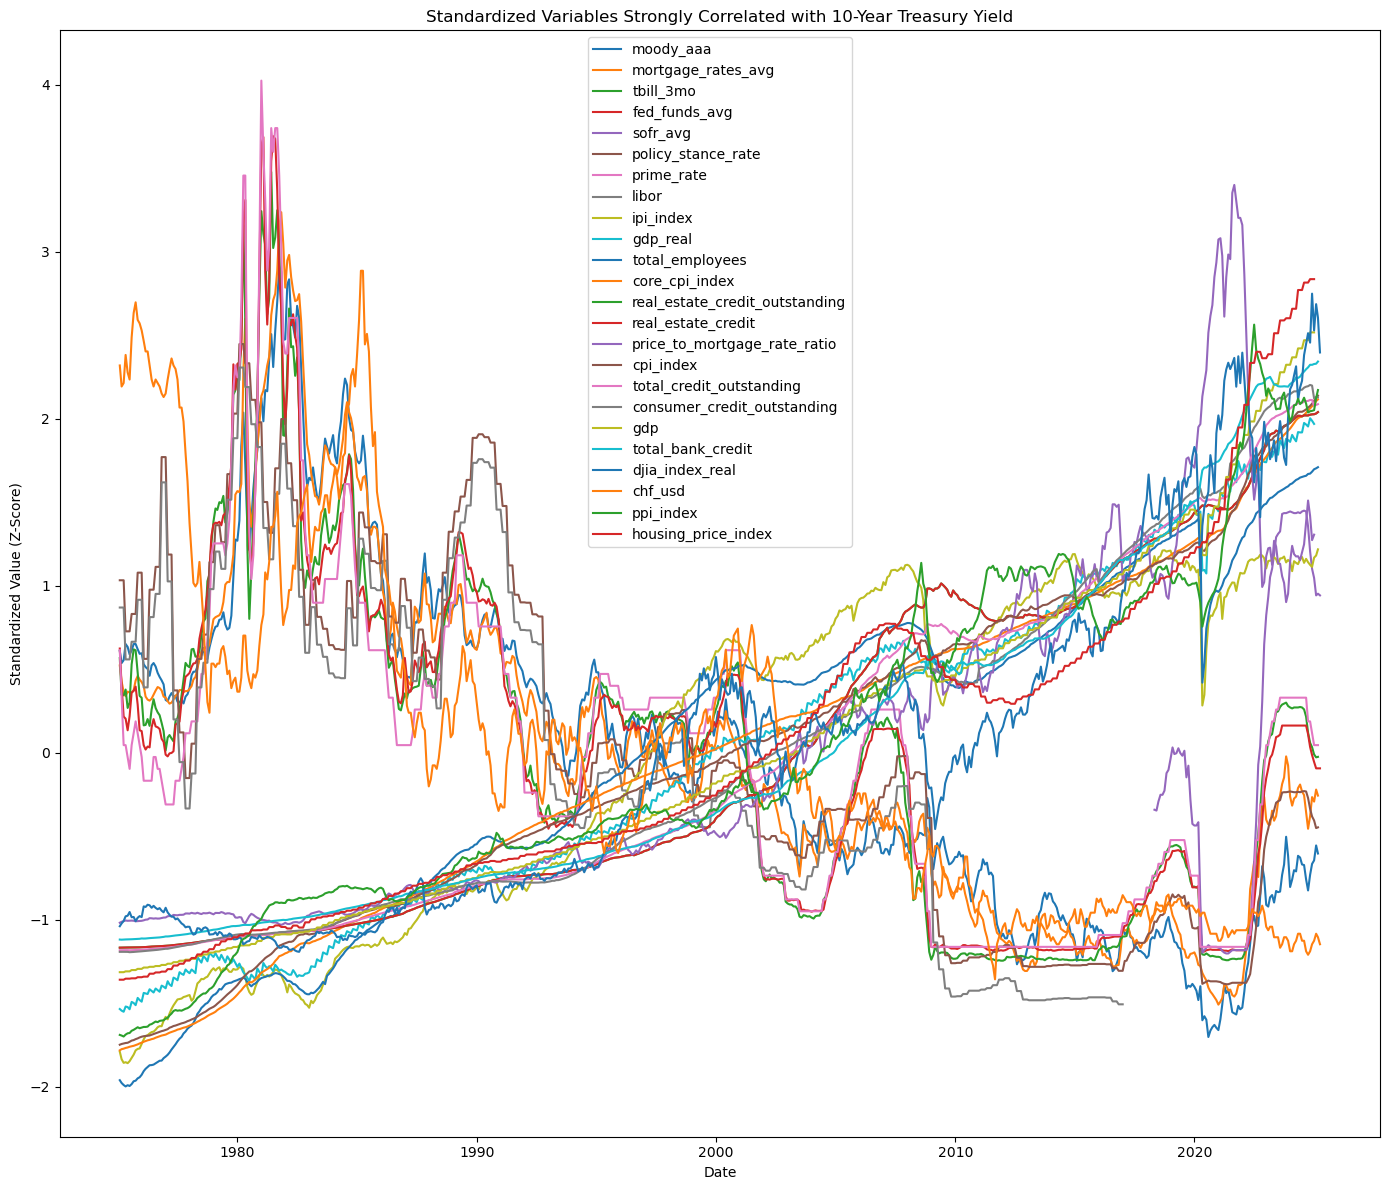

In [127]:
#all strong corrs >.75 w/ tsec as target and scaling

tsec_stronger_corr_vars_df = combined_df[tsec_stronger_corr_vars]

scaler = StandardScaler()
tsec_stronger_corr_vars_scaled = pd.DataFrame(
    scaler.fit_transform(tsec_stronger_corr_vars_df),
    columns = tsec_stronger_corr_vars_df.columns,
    index = tsec_stronger_corr_vars_df.index
)

plt.figure(figsize=(14, 12))

for column in tsec_stronger_corr_vars_scaled.columns:
        plt.plot(tsec_stronger_corr_vars_scaled.index, tsec_stronger_corr_vars_scaled[column], label=column)

plt.title('Standardized Variables Strongly Correlated with 10-Year Treasury Yield')
plt.xlabel('Date')
plt.ylabel('Standardized Value (Z-Score)')
plt.legend()
plt.tight_layout()

plt.savefig("line_all_stronger_corr_scaled.png", dpi=300, bbox_inches='tight')

plt.show()

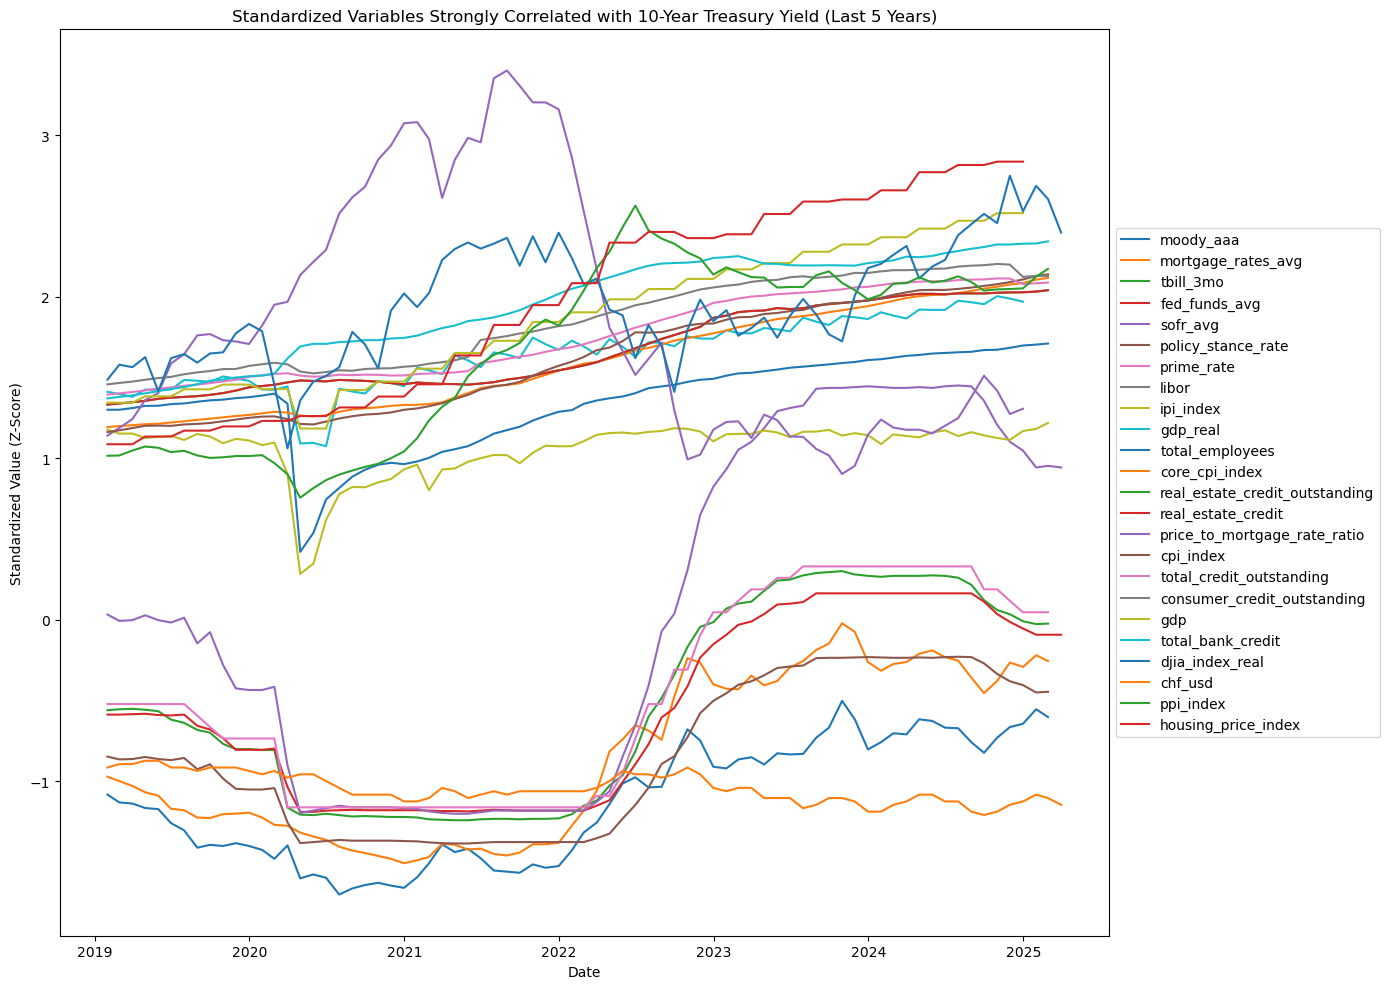

In [129]:
#limiting to 5 years
tsec_stronger_corr_vars_scaled.index = pd.to_datetime(tsec_stronger_corr_vars_scaled.index)

last_5_years = tsec_stronger_corr_vars_scaled.loc[tsec_stronger_corr_vars_scaled.index >= '2019-01-01']

plt.figure(figsize=(14, 10))

for column in last_5_years.columns:
    plt.plot(last_5_years.index, last_5_years[column], label=column)

plt.title("Standardized Variables Strongly Correlated with 10-Year Treasury Yield (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Standardized Value (Z-Score)")
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

plt.savefig("line_stronger_corr_scaled_5yrs.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#top predictive variables
#create lag 1-3 months back to see what corrs we have to predict tsec
for var in tsec_stronger_corr_vars:
    for lag in [1, 2, 3]:
        combined_df[f"{var}_lag{lag}"] = combined_df[var].shift(lag)

lagged_corr = combined_df.select_dtypes(include='number').corr()['tsec_10yr_avg']
lagged_corr = lagged_corr.drop('tsec_10yr_avg')

lagged_indicators = lagged_corr[lagged_corr.index.str.contains('_lag')]


pd.set_option('display.max_rows', None)
print(lagged_indicators)

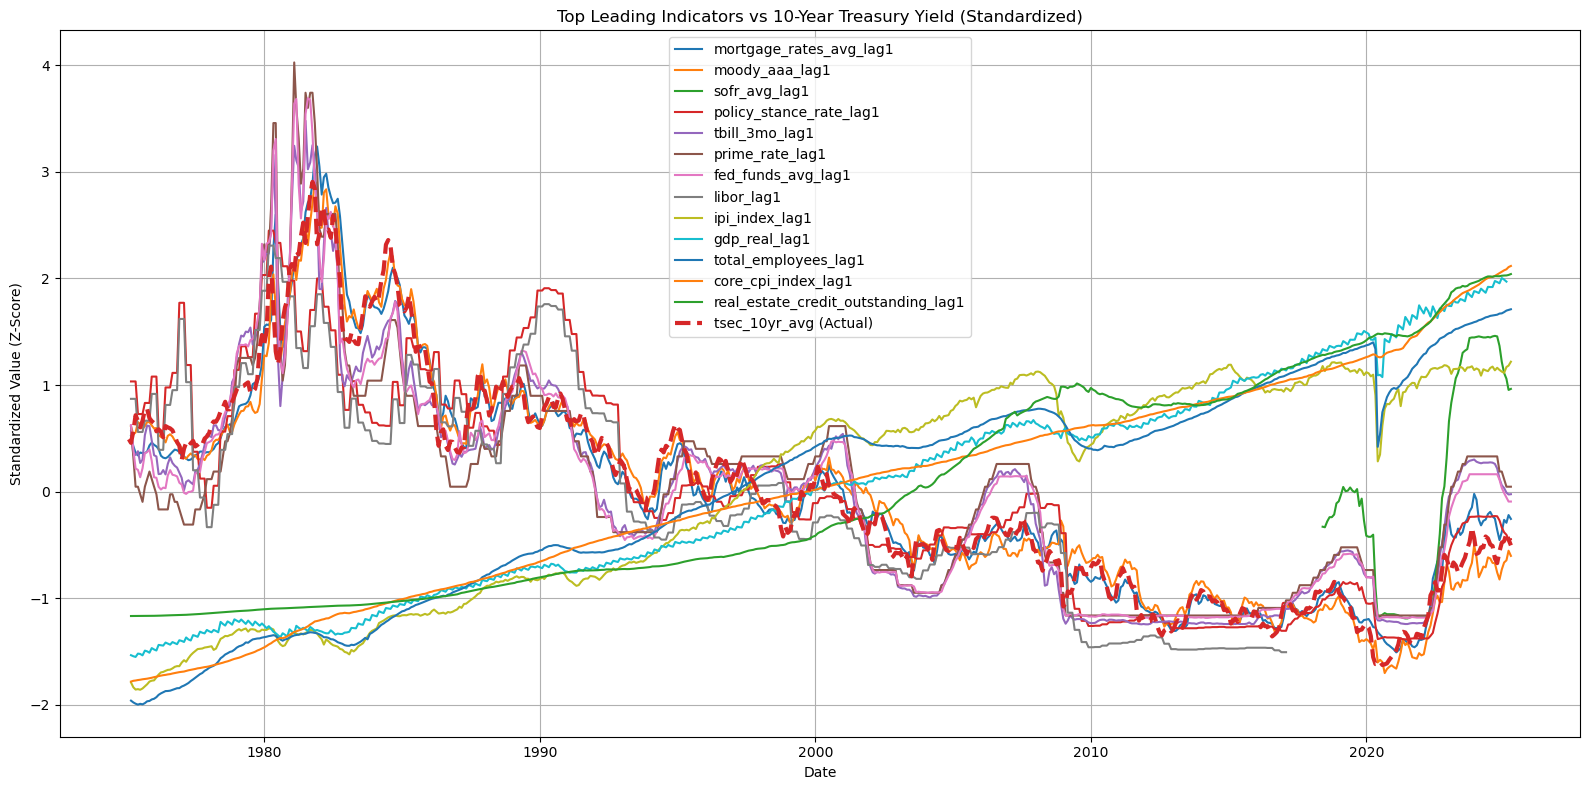

In [131]:
#ploting top corrs but need to scale
top_lagged = [
    'mortgage_rates_avg_lag1',
    'moody_aaa_lag1',
    'sofr_avg_lag1',
    'policy_stance_rate_lag1',
    'tbill_3mo_lag1',
    'prime_rate_lag1',
    'fed_funds_avg_lag1',
    'libor_lag1',
    'ipi_index_lag1',
    'gdp_real_lag1',
    'total_employees_lag1',
    'core_cpi_index_lag1',
    'real_estate_credit_outstanding_lag1',
]

top_lagged_with_target = top_lagged + ['tsec_10yr_avg']
top_lagged_df = combined_df[top_lagged_with_target]  

scaler = StandardScaler()
top_lagged_scaled_df = pd.DataFrame(
    scaler.fit_transform(top_lagged_df),
    columns=top_lagged_df.columns,
    index=top_lagged_df.index
)


plt.figure(figsize=(16, 8))
for col in top_lagged:
    plt.plot(top_lagged_scaled_df.index, top_lagged_scaled_df[col], label=col)

plt.plot(top_lagged_scaled_df.index, top_lagged_scaled_df['tsec_10yr_avg'], label='tsec_10yr_avg (Actual)', linewidth=3, linestyle='--')       
plt.title("Top Leading Indicators vs 10-Year Treasury Yield (Standardized)")
plt.xlabel("Date")
plt.ylabel("Standardized Value (Z-Score)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("line_all_corr_scaled_lagged.png", dpi=300, bbox_inches='tight')

plt.show()

    

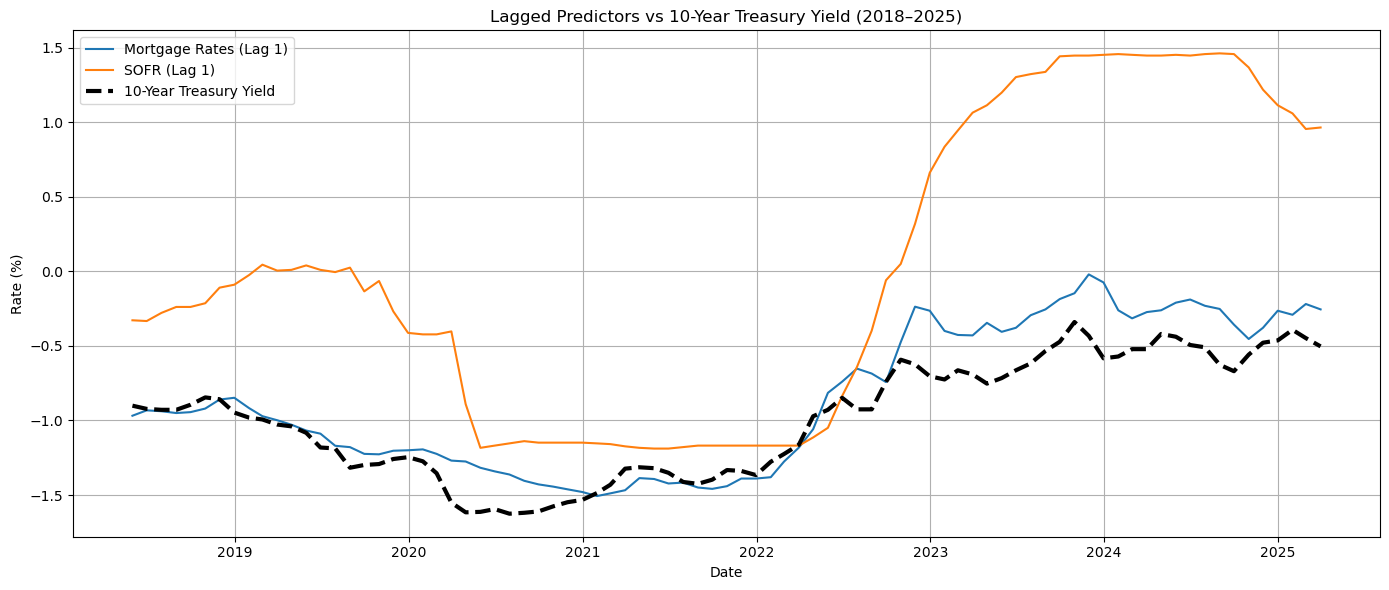

In [133]:
#zoom into 2018-current, these are months where there seems to be the most activity
top_lagged_scaled_df.index = pd.to_datetime(top_lagged_scaled_df.index)
top_lagged_scaled_df = top_lagged_scaled_df.sort_index()

zoom_df = top_lagged_scaled_df.loc[(top_lagged_scaled_df.index >= '2018-01-01')]

plot_zoom = zoom_df[['mortgage_rates_avg_lag1', 'sofr_avg_lag1', 'tsec_10yr_avg']].dropna()

plt.figure(figsize=(14, 6))
plt.plot(plot_zoom.index, plot_zoom['mortgage_rates_avg_lag1'], label='Mortgage Rates (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['sofr_avg_lag1'], label='SOFR (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['tsec_10yr_avg'], label='10-Year Treasury Yield', color='black', linewidth=3, linestyle='--')

plt.title("Lagged Predictors vs 10-Year Treasury Yield (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("line_mtg_int_lag_corr.png", dpi=300, bbox_inches='tight')

plt.show()

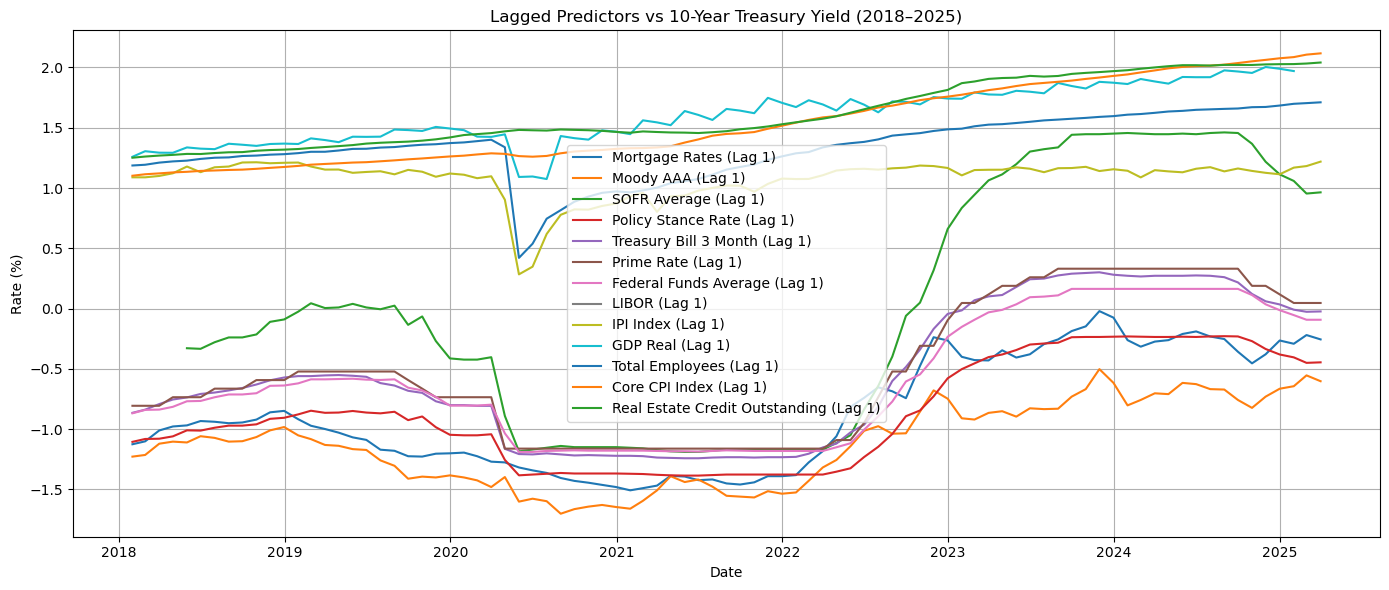

In [135]:
#let's do all scaled and zoomed in
zoom_df.index = pd.to_datetime(zoom_df.index)
zoom_df = zoom_df.sort_index()

zoom_df = zoom_df.loc[(zoom_df.index >= '2018-01-01')]

plot_zoom = zoom_df[['mortgage_rates_avg_lag1', 'moody_aaa_lag1', 'sofr_avg_lag1', 
                     'policy_stance_rate_lag1', 'tbill_3mo_lag1', 'prime_rate_lag1', 'fed_funds_avg_lag1',
                     'libor_lag1', 'ipi_index_lag1', 'gdp_real_lag1', 'total_employees_lag1',
                     'core_cpi_index_lag1', 'real_estate_credit_outstanding_lag1']]    #.dropna()

plt.figure(figsize=(14, 6))
plt.plot(plot_zoom.index, plot_zoom['mortgage_rates_avg_lag1'], label='Mortgage Rates (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['moody_aaa_lag1'], label='Moody AAA (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['sofr_avg_lag1'], label='SOFR Average (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['policy_stance_rate_lag1'], label='Policy Stance Rate (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['tbill_3mo_lag1'], label='Treasury Bill 3 Month (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['prime_rate_lag1'], label='Prime Rate (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['fed_funds_avg_lag1'], label='Federal Funds Average (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['libor_lag1'], label='LIBOR (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['ipi_index_lag1'], label='IPI Index (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['gdp_real_lag1'], label='GDP Real (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['total_employees_lag1'], label='Total Employees (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['core_cpi_index_lag1'], label='Core CPI Index (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['real_estate_credit_outstanding_lag1'], label='Real Estate Credit Outstanding (Lag 1)', linestyle='-')

plt.title("Lagged Predictors vs 10-Year Treasury Yield (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("line_stronger_lag_scale_corr.png", dpi=300, bbox_inches='tight')

plt.show()

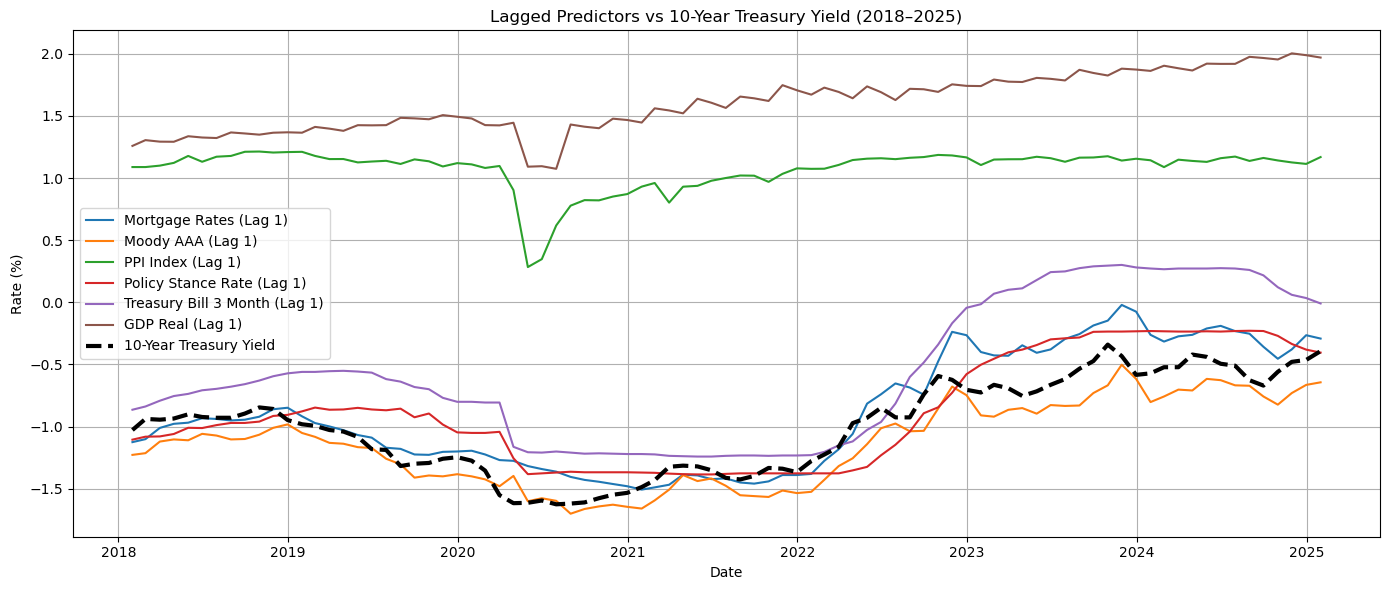

In [137]:
#zoom on top 6 corr scaled
zoom_df.index = pd.to_datetime(zoom_df.index)
zoom_df = zoom_df.sort_index()

zoom_df = zoom_df.loc[(zoom_df.index >= '2018-01-01')]

plot_zoom = zoom_df[['mortgage_rates_avg_lag1', 'moody_aaa_lag1', 'policy_stance_rate_lag1', 
                     'ipi_index_lag1', 'tbill_3mo_lag1', 'gdp_real_lag1', 'tsec_10yr_avg']].dropna()

plt.figure(figsize=(14, 6))
plt.plot(plot_zoom.index, plot_zoom['mortgage_rates_avg_lag1'], label='Mortgage Rates (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['moody_aaa_lag1'], label='Moody AAA (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['ipi_index_lag1'], label='PPI Index (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['policy_stance_rate_lag1'], label='Policy Stance Rate (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['tbill_3mo_lag1'], label='Treasury Bill 3 Month (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['gdp_real_lag1'], label='GDP Real (Lag 1)', linestyle='-')
plt.plot(plot_zoom.index, plot_zoom['tsec_10yr_avg'], label='10-Year Treasury Yield', color='black', linewidth=3, linestyle='--')

plt.title("Lagged Predictors vs 10-Year Treasury Yield (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("line_best6_lag_scale_corr.png", dpi=300, bbox_inches='tight')

plt.show()

In [37]:
#we have feb data for all 6 top indicators so let's see if we can predict 3/31
indicators = [
    'mortgage_rates_avg_lag1',
    'moody_aaa_lag1',
    'policy_stance_rate_lag1',
    'tbill_3mo_lag1',
    'ipi_index_lag1',
    'gdp_real_lag1'
]

#get percent change
monthly_pct_change = top_lagged_scaled_df[indicators].pct_change()

#get most recent 2 months
feb_date = '2025-02-28'
jan_date = '2025-01-31'

feb_values = top_lagged_scaled_df.loc[feb_date, indicators]
jan_values = top_lagged_scaled_df.loc[jan_date, indicators]
feb_change = monthly_pct_change.loc[feb_date, indicators]

#scoring indicator movements to try and predict
scoring_rules = {
    'mortgage_rates_avg_lag1': -1, #increase rate = bad. these are already tight and precede TSEC peak or fall
    'moody_aaa_lag1': -1, #increase yields is good but higher yields = tighter credit conditions and slower growth, TSEC may fall
    'policy_stance_rate_lag1': -1, #increase rate is bad, credit costs more
    'tbill_3mo_lag1': -1, #increase rate is good but = tighter credit conditions and slower growth, TSEC may fall
    'ipi_index_lag1': 1, #rise is inflation pressure which indicates higher rates to come so TSEC may increase
    'gdp_real_lag1': 1 #increase in gdp is good
}

#scoring
direction_monthly_change = (feb_change > 0).astype(int)
score = sum(direction_monthly_change[var] * scoring_rules[var] for var in scoring_rules)

if score >= 3:
    prediction = "Rates likely to increase in March 2025"
elif score <= -3:
    prediction = "Rates likely to decrease in March 2025"
elif -2 <= score <= 2:
    prediction = "Uncertain or stable rate forecast"

#calc individual scores just in case
indicator_score = {
    var: (1 if feb_change[var] > 0 else -1) * scoring_rules[var]
    for var in indicators
}

#make a df to show results in an easy format
monthly_change = pd.DataFrame({
    'Jan': jan_values.astype(float),
    'Feb': feb_values.astype(float),
    'Change %': ((feb_values.astype(float) - jan_values.astype(float)) / jan_values.astype(float) * 100).round(2),
    'Score': pd.Series(indicator_score) #HA threw this in there because I have it
})

print("Prediction for 10-Year Treasury Yield (March 2025):", prediction)
print("\nIndicator Movements:\n", monthly_change)
print("\n Total Score:", score)

Prediction for 10-Year Treasury Yield (March 2025): Uncertain or stable rate forecast

Indicator Movements:
                               Jan       Feb  Change %  Score
mortgage_rates_avg_lag1 -0.291571 -0.219373    -24.76      1
moody_aaa_lag1          -0.643577 -0.553752    -13.96      1
policy_stance_rate_lag1 -0.404364 -0.449912     11.26     -1
tbill_3mo_lag1          -0.009042 -0.026434    192.33     -1
ipi_index_lag1           1.168929  1.181851      1.11      1
gdp_real_lag1            1.969632       NaN       NaN     -1

 Total Score: -1


C:\Users\amybr\AppData\Local\Temp\ipykernel_31640\1942305012.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_pct_change = top_lagged_scaled_df[indicators].pct_change()


In [38]:
#let's see if this works, first finding most volatile month with >1% change
tsec_monthly_change = combined_df['tsec_10yr_avg'].pct_change()
tsec_monthly_change = tsec_monthly_change.loc['2010-08-01':]

#getting one over 1% change, combined_df starts 7/2010 due to unavailable data so need to use values after that
volatile_months = tsec_monthly_change[abs(tsec_monthly_change) > .01]

#abs most volatile one date
most_volatile_date = volatile_months.abs().idxmax()

print("Most volatile month for 10 year treasury yield:", most_volatile_date)

Most volatile month for 10 year treasury yield: 2020-03-31 00:00:00


In [39]:
#set dates
target_date = pd.to_datetime('2020-03-31')
prev_month = target_date - pd.DateOffset(months=1)
two_months_ago = target_date - pd.DateOffset(months=2)

#get values
prev_month_values = top_lagged_scaled_df.loc[prev_month, indicators]
two_months_ago_values = top_lagged_scaled_df.loc[two_months_ago, indicators]

#get percent change
monthly_change = (prev_month_values - two_months_ago_values) / two_months_ago_values * 100

#scoring
direction_monthly_change = (monthly_change > 0).astype(int)

score = sum(direction_monthly_change[var] * scoring_rules[var] for var in scoring_rules)

if score >= 3:
    prediction = f"Rates likely to increase in {target_date.strftime('%B %Y')}"
elif score <= -3:
    prediction = f"Rates likely to decrease in {target_date.strftime('%B %Y')}"
elif -2 <= score <= 2:
    prediction = f"Uncertain or stable rate forecast"

#calc individual scores just in case
indicator_score = {
    var: (1 if monthly_change[var] > 0 else -1) * scoring_rules[var]
    for var in indicators
}

#make a df to show results in an easy format
monthly_change = pd.DataFrame({
    two_months_ago.strftime('%B %Y'): two_months_ago,
    prev_month.strftime('%B %Y'): prev_month,
    'Change %': monthly_change,
    'Score': pd.Series(indicator_score) #HA threw this in there because I have it
})

print(f"Prediction for 10-Year Treasury Yield ({target_date}):", prediction)
print("\nIndicator Movements:\n", monthly_change)
print("\n Total Score:", score)


Prediction for 10-Year Treasury Yield (2020-03-31 00:00:00): Rates likely to decrease in March 2020

Indicator Movements:
                         January 2020 February 2020  Change %  Score
mortgage_rates_avg_lag1   2020-01-31    2020-02-29  2.519377     -1
moody_aaa_lag1            2020-01-31    2020-02-29  1.727184     -1
policy_stance_rate_lag1   2020-01-31    2020-02-29 -0.000000      1
tbill_3mo_lag1            2020-01-31    2020-02-29  0.724324     -1
ipi_index_lag1            2020-01-31    2020-02-29 -2.586937     -1
gdp_real_lag1             2020-01-31    2020-02-29 -3.613955     -1

 Total Score: -3


In [40]:
combined_df.loc['2020-03-31', 'tsec_10yr_avg']

0.87

In [41]:
combined_df.loc['2020-02-29', 'tsec_10yr_avg']

1.51